In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
url = 'https://raw.githubusercontent.com/hjhuney/Data/master/AmesHousing/train.csv'

In [3]:
df=pd.read_csv(url)

# 1.Data Inspection

In [4]:
print(f"Data Shape: {df.shape}")

Data Shape: (1460, 81)


In [5]:
numeric_dtypes = df.select_dtypes(exclude="str")
string_dtypes = df.select_dtypes(include="str")

numeric_columns = pd.DataFrame({
    "Numeric" : numeric_dtypes.columns
}).reset_index(drop=True)

categorical_columns = pd.DataFrame({
    "String" : string_dtypes.columns
}).reset_index(drop=True)


In [6]:
null_values = df.isnull().sum()

null_values = null_values[ null_values > 0 ]

null_percentage =( ( null_values / df.shape[0] ) * 100 ).round(2)


null_data = pd.DataFrame({
    "Columns" : null_values.index,
    "Null %" : null_percentage
}).sort_values("Null %" , ascending=False).reset_index(drop=True)

null_data

,Columns,Null %
0,PoolQC,99.52
1,MiscFeature,96.30
2,Alley,93.77
3,Fence,80.75
4,MasVnrType,59.73
5,FireplaceQu,47.26
6,LotFrontage,17.74
7,GarageType,5.55
8,GarageYrBlt,5.55
9,GarageFinish,5.55


# 2.Target Variable Analysis (SalePrice)

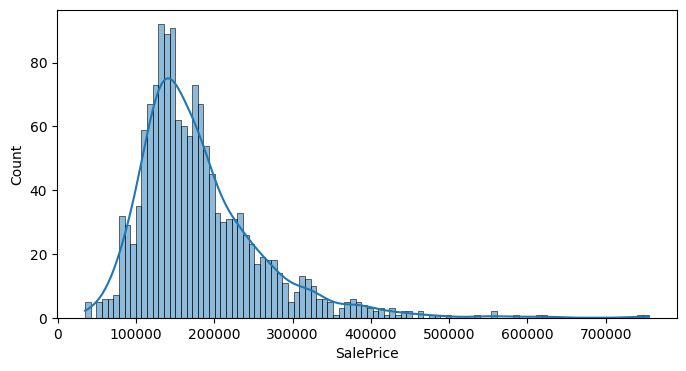

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(df["SalePrice"] , bins=100 , kde=True)
plt.show()

sale_price_log = np.log1p(df["SalePrice"])


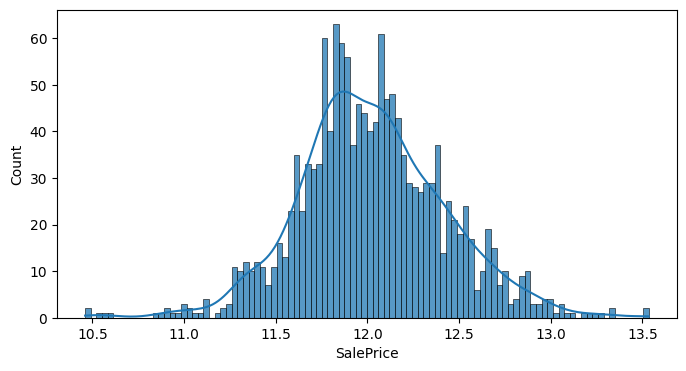

In [8]:
sale_price_log = np.log1p(df["SalePrice"])
plt.figure(figsize=(8,4))
sns.histplot(sale_price_log , bins=100 , kde=True , alpha=0.75)
plt.show()


# sale_price_log = np.log1p(df["SalePrice"])

# plt.figure(figsize=(10,5))

# sns.histplot(
#     sale_price_log,
#     bins=50,
#     kde=True,
#     color="steelblue",
#     edgecolor="black"
# )

# plt.axvline(
#     sale_price_log.mean(),
#     color="red",
#     linestyle="--",
#     linewidth=2,
#     label=f"Mean = {sale_price_log.mean():.2f}"
# )

# plt.axvline(
#     sale_price_log.median(),
#     color="green",
#     linestyle="-.",
#     linewidth=2,
#     label=f"Median = {sale_price_log.median():.2f}"
# )

# plt.title("Log Transformed SalePrice Distribution")
# plt.xlabel("Log(SalePrice)")
# plt.ylabel("Frequency")

# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()

In [9]:
df.drop("Id" , inplace=True , axis=1)

In [10]:
mean_of_cols = df.describe().loc["mean"]
median_of_cols = df.describe().loc["50%"]

diff = (mean_of_cols - median_of_cols) / mean_of_cols

right_skewed_cols = diff[diff > 0.1].index
left_skewed_cols = diff[diff < -0.1].index
symmetric_cols = diff[(diff >= -0.1) & (diff <= 0.1)].index

print("Right Skewed:", list(right_skewed_cols))
print("Left Skewed :", list(left_skewed_cols))
print("Symmetric   :", list(symmetric_cols))


Right Skewed: ['MSSubClass', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
Left Skewed : ['FullBath', 'Fireplaces', 'GarageCars']
Symmetric   : ['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea', 'MoSold', 'YrSold', 'SalePrice']


# 3. Numerical Features EDA + Statistical Inference

In [11]:
num_cols = df.select_dtypes(include=np.number)


In [12]:
target_corr = num_cols.corr()["SalePrice"]

target_corr = target_corr[ (target_corr > 0.5 ) | (target_corr < -0.5) ]
target_corr = target_corr.drop("SalePrice")
cols = np.array(target_corr.index)
len(cols)

10

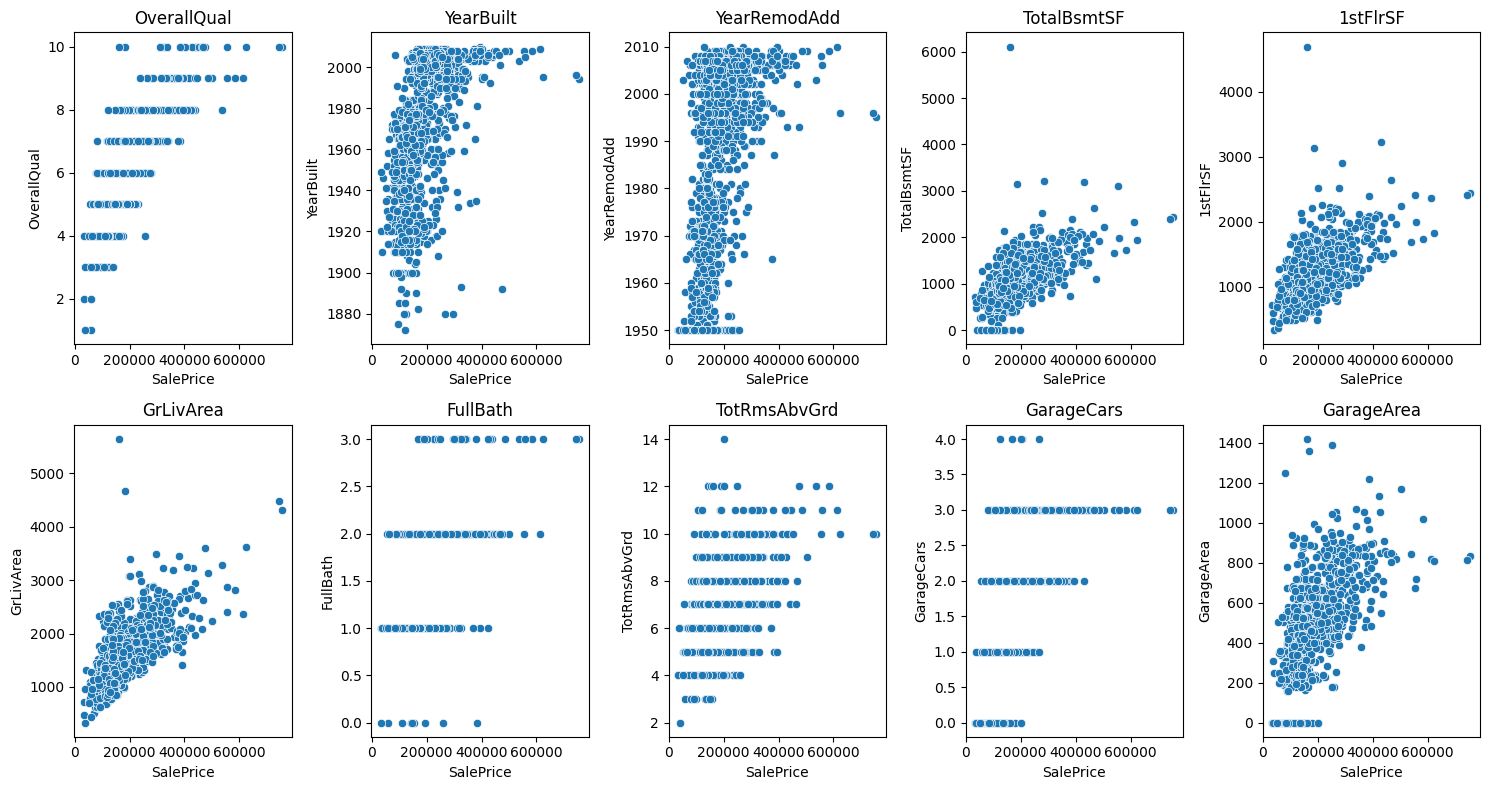

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8))  # rows, cols
axes = axes.ravel()  # 2D ko 1D bana diya

for i, col in enumerate(cols):
    sns.scatterplot(
        x=df["SalePrice"],
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Pearson Correlation + Hypothesis Testing

In [14]:
from scipy.stats import pearsonr

numeric_df = df.select_dtypes(include=[np.number])

correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print("Top correlated features (sirf r):")
print(correlations)

Top correlated features (sirf r):
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name

In [15]:
# Har numeric feature ke liye r AND p-value dono nikaalo
results = []

for col in numeric_df.columns:
    if col == 'SalePrice':
        continue  # target ko target ke saath test nahi karna
    
    # pearsonr NaN values handle nahi karta, isliye dropna zaroori hai
    # dono columns ko saath mein align karna padega (same rows drop ho)
    valid_data = df[[col, 'SalePrice']].dropna()
    
    r, p_value = pearsonr(valid_data[col], valid_data['SalePrice'])
    
    results.append({
        'feature': col,
        'correlation': r,
        'p_value': p_value,
        'abs_correlation': abs(r)
    })

# Result ko ek clean dataframe mein convert karo, sort karo
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('abs_correlation', ascending=False)

print(results_df)

          feature  correlation        p_value  abs_correlation
3     OverallQual     0.790982  2.185675e-313         0.790982
15      GrLivArea     0.708624  4.518034e-223         0.708624
25     GarageCars     0.640409  2.498644e-169         0.640409
26     GarageArea     0.623431  5.265038e-158         0.623431
11    TotalBsmtSF     0.613581  9.484229e-152         0.613581
12       1stFlrSF     0.605852  5.394711e-147         0.605852
18       FullBath     0.560664  1.236470e-121         0.560664
22   TotRmsAbvGrd     0.533723  2.772281e-108         0.533723
5       YearBuilt     0.522897  2.990229e-103         0.522897
6    YearRemodAdd     0.507101   3.164948e-96         0.507101
24    GarageYrBlt     0.486362   8.705128e-83         0.486362
7      MasVnrArea     0.477493   1.458509e-83         0.477493
23     Fireplaces     0.466929   6.141487e-80         0.466929
8      BsmtFinSF1     0.386420   3.394110e-53         0.386420
1     LotFrontage     0.351799   2.602442e-36         0

In [16]:
# Statistically significant AND practically strong features
significant_features = results_df[
    (results_df['p_value'] < 0.05) & (results_df['abs_correlation'] > 0.3)
]

print("\nGenuinely important features (p < 0.05 AND |r| > 0.3):")
print(significant_features)


Genuinely important features (p < 0.05 AND |r| > 0.3):
         feature  correlation        p_value  abs_correlation
3    OverallQual     0.790982  2.185675e-313         0.790982
15     GrLivArea     0.708624  4.518034e-223         0.708624
25    GarageCars     0.640409  2.498644e-169         0.640409
26    GarageArea     0.623431  5.265038e-158         0.623431
11   TotalBsmtSF     0.613581  9.484229e-152         0.613581
12      1stFlrSF     0.605852  5.394711e-147         0.605852
18      FullBath     0.560664  1.236470e-121         0.560664
22  TotRmsAbvGrd     0.533723  2.772281e-108         0.533723
5      YearBuilt     0.522897  2.990229e-103         0.522897
6   YearRemodAdd     0.507101   3.164948e-96         0.507101
24   GarageYrBlt     0.486362   8.705128e-83         0.486362
7     MasVnrArea     0.477493   1.458509e-83         0.477493
23    Fireplaces     0.466929   6.141487e-80         0.466929
8     BsmtFinSF1     0.386420   3.394110e-53         0.386420
1    LotFronta

### Correlation Heatmap

(37, 37)


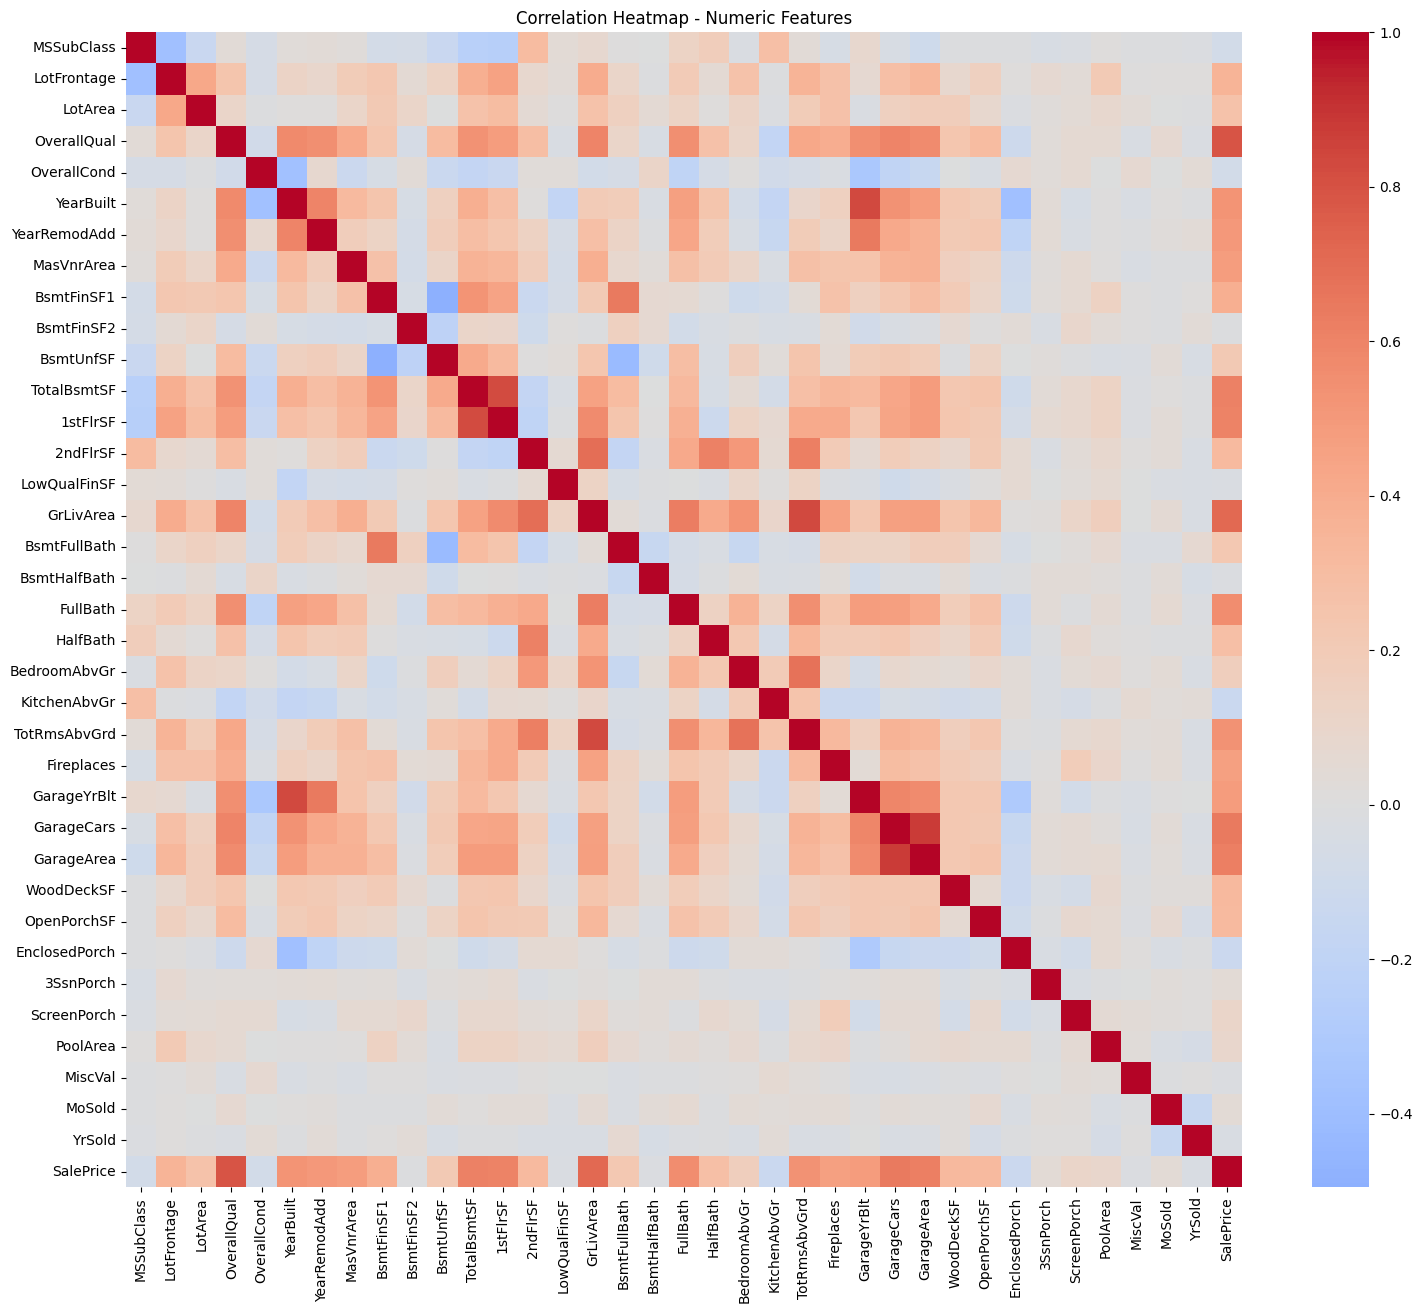

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# STEP A: Sabhi numeric features ka correlation matrix banao
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

print(corr_matrix.shape)  # (n_features, n_features) - square matrix hoga

# STEP B: Heatmap se visualize karo
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_57856\2635705578.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='correlation', y='feature', palette='coolwarm')


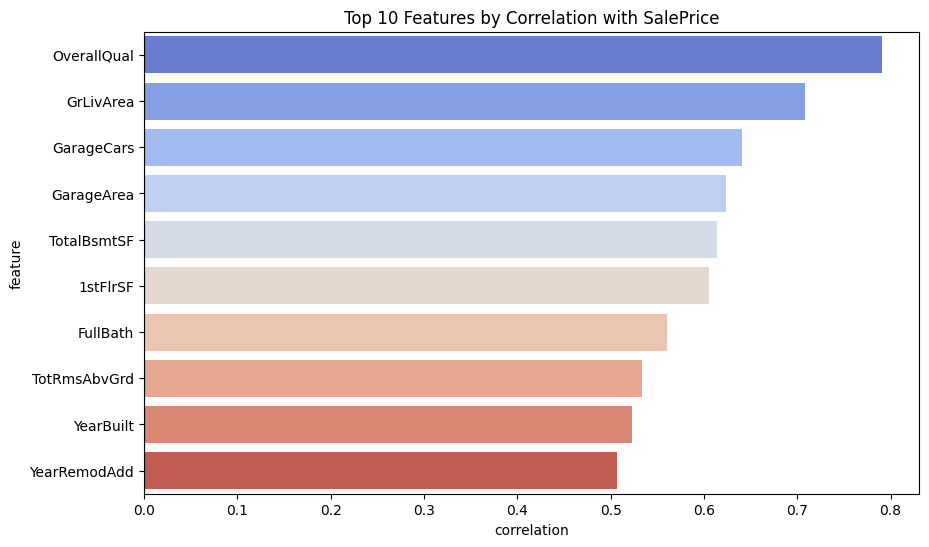

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 = results_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x='correlation', y='feature', palette='coolwarm')
plt.title('Top 10 Features by Correlation with SalePrice')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# 4. Multicollinearity Check (VIF)

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# FIX: NaN values check karo aur handle karo VIF se pehle

print("Missing values before fix:")
print(numeric_df.isnull().sum()[numeric_df.isnull().sum() > 0])

# Option A: Simple - NaN rows drop (sirf VIF calculation ke liye, temporary)
numeric_df_clean = numeric_df.dropna()

print("\nShape before:", numeric_df.shape, "-> after dropna:", numeric_df_clean.shape)

# Ab VIF calculate karo clean data pe
vif_data = pd.DataFrame()
vif_data['feature'] = numeric_df_clean.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_df_clean.values, i) 
                   for i in range(numeric_df_clean.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Missing values before fix:
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

Shape before: (1460, 37) -> after dropna: (1121, 37)
          feature           VIF
12       1stFlrSF           inf
9      BsmtFinSF2           inf
10      BsmtUnfSF           inf
11    TotalBsmtSF           inf
8      BsmtFinSF1           inf
14   LowQualFinSF           inf
15      GrLivArea           inf
13       2ndFlrSF           inf
24    GarageYrBlt  2.681653e+04
35         YrSold  2.581520e+04
5       YearBuilt  2.496220e+04
6    YearRemodAdd  2.454835e+04
22   TotRmsAbvGrd  8.467821e+01
3     OverallQual  8.389702e+01
4     OverallCond  5.031102e+01
21   KitchenAbvGr  4.245122e+01
25     GarageCars  4.064952e+01
26     GarageArea  3.518325e+01
20   BedroomAbvGr  3.451432e+01
36      SalePrice  3.149748e+01
18       FullBath  2.880735e+01
1     LotFrontage  1.736994e+01
34         MoSold  6.842297e+00
0      MSSubClass  4.971791e+00
16   BsmtFullBath  3.677852e+00
19       HalfBath

In [20]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data['feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) 
                        for i in range(df.shape[1])]
    return vif_data

# FIX: NaN handle karo copy() se pehle ya turant baad
numeric_df_reduced = numeric_df.fillna(numeric_df.median()).copy()

while True:
    vif_result = calculate_vif(numeric_df_reduced)
    max_vif = vif_result['VIF'].max()
    
    if max_vif > 10:
        feature_to_drop = vif_result.loc[vif_result['VIF'].idxmax(), 'feature']
        print(f"Dropping '{feature_to_drop}' with VIF = {max_vif:.2f}")
        numeric_df_reduced = numeric_df_reduced.drop(feature_to_drop, axis=1)
    else:
        break

print("\nFinal features after VIF filtering:")
print(calculate_vif(numeric_df_reduced))

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'BsmtFinSF1' with VIF = inf
Dropping '1stFlrSF' with VIF = inf


c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'YrSold' with VIF = 25091.86
Dropping 'GarageYrBlt' with VIF = 20493.76
Dropping 'YearRemodAdd' with VIF = 13646.64
Dropping 'YearBuilt' with VIF = 120.21
Dropping 'GrLivArea' with VIF = 103.76
Dropping 'TotRmsAbvGrd' with VIF = 70.10
Dropping 'OverallQual' with VIF = 58.10
Dropping 'GarageCars' with VIF = 35.46
Dropping 'KitchenAbvGr' with VIF = 25.56
Dropping 'TotalBsmtSF' with VIF = 25.24
Dropping 'SalePrice' with VIF = 19.91
Dropping 'BedroomAbvGr' with VIF = 19.22
Dropping 'FullBath' with VIF = 14.71
Dropping 'LotFrontage' with VIF = 13.03

Final features after VIF filtering:
          feature       VIF
0      MSSubClass  3.026369
1         LotArea  2.427434
2     OverallCond  9.958883
3      MasVnrArea  1.662661
4      BsmtFinSF2  1.191464
5       BsmtUnfSF  3.674175
6        2ndFlrSF  3.279073
7    LowQualFinSF  1.043973
8    BsmtFullBath  2.629756
9    BsmtHalfBath  1.167284
10       HalfBath  2.678714
11     Fireplaces  2.450941
12     GarageArea  7.636679
13     Wood

# 5. Categorical Features EDA

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import pandas as pd

# STEP A: Categorical columns nikaalo

cat_cols = df.select_dtypes(include=['str']).columns.tolist()
print(f"Total categorical columns: {len(cat_cols)}")

Total categorical columns: 43


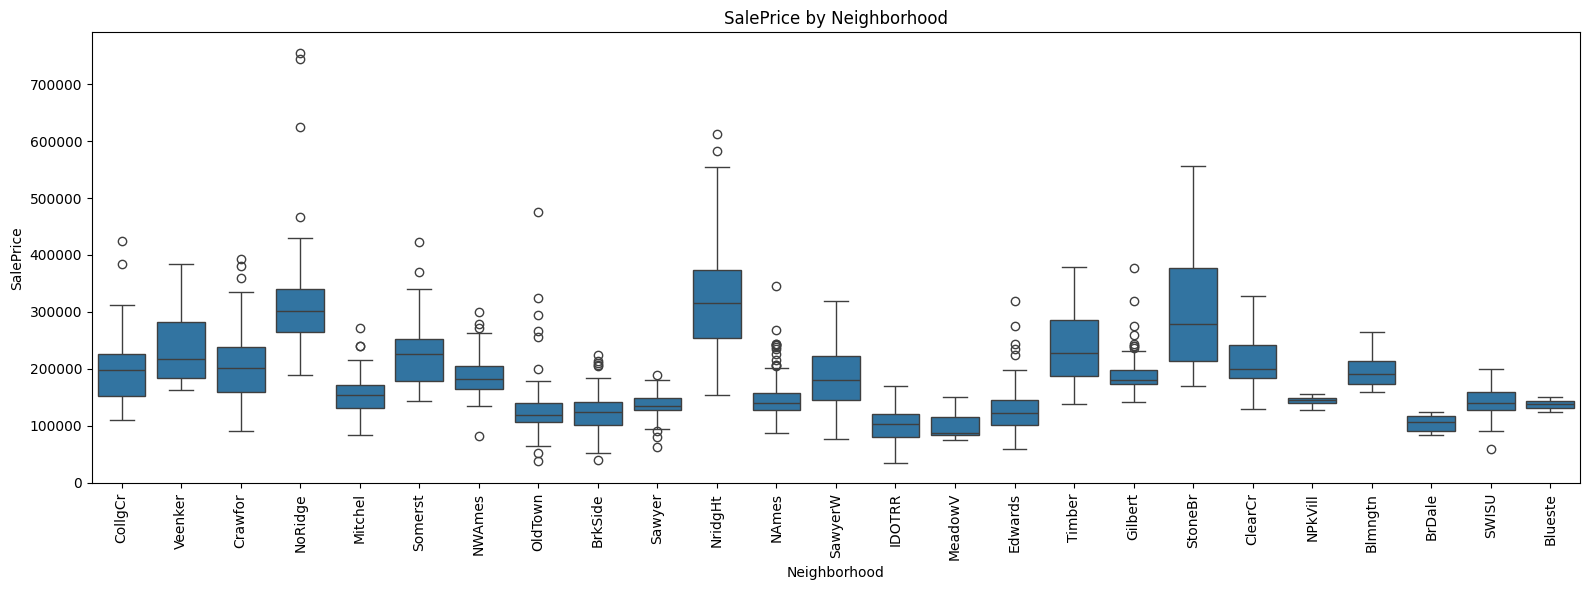

In [22]:
# Nominal example - Neighborhood
plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood')
plt.tight_layout()
plt.show()


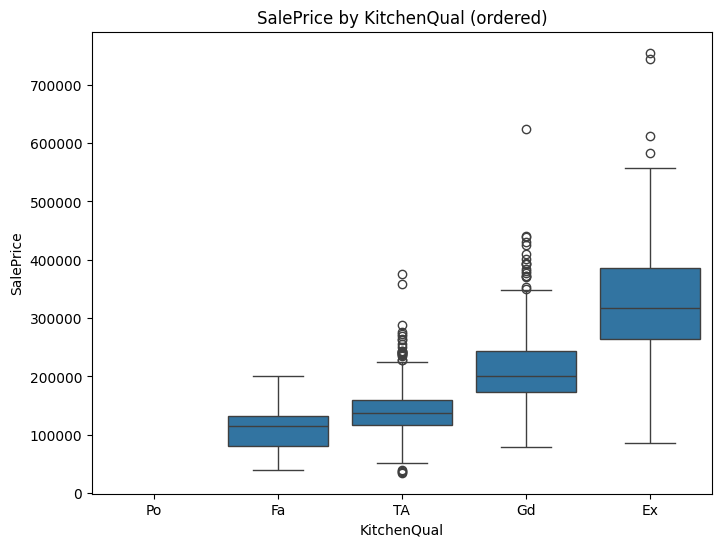

In [23]:
# Ordinal example - KitchenQual (logical order mein plot karo)
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']  # sirf woh categories jo actually is column mein exist karti hai

plt.figure(figsize=(8, 6))
sns.boxplot(x='KitchenQual', y='SalePrice', data=df, order=quality_order)
plt.title('SalePrice by KitchenQual (ordered)')
plt.show()

In [24]:


# STEP C: Har categorical column pe ANOVA chalao, result table banao

anova_results = []

for col in cat_cols:
    # Har category ke liye SalePrice ka group banao
    groups = [df[df[col] == cat]['SalePrice'].dropna() for cat in df[col].dropna().unique()]
    
    # Agar kisi category mein sirf 1 hi value hai, ya groups bahut kam hai, skip karo (error avoid karne ke liye)
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        continue
    
    f_stat, p_value = f_oneway(*groups)
    
    anova_results.append({
        'feature': col,
        'F_statistic': f_stat,
        'p_value': p_value,
        'n_categories': df[col].nunique()
    })

anova_df = pd.DataFrame(anova_results)
anova_df = anova_df.sort_values('F_statistic', ascending=False)
print(anova_df)

          feature  F_statistic        p_value  n_categories
17      ExterQual   443.334831  1.439551e-204             4
29    KitchenQual   407.806352  3.032213e-192             4
20       BsmtQual   392.913506  9.610615e-186             4
33   GarageFinish   250.962467   1.199117e-93             3
26      HeatingQC   117.281347   5.041729e-68             5
19     Foundation   100.253851   5.791895e-91             6
27     CentralAir    98.305344   1.809506e-22             2
7    Neighborhood    71.784865  1.558600e-225            25
32     GarageType    71.522123   1.247154e-66             6
22   BsmtExposure    70.887984   1.022671e-42             4
23   BsmtFinType1    67.602175   1.807731e-63             6
41  SaleCondition    45.578428   7.988268e-44             6
0        MSZoning    43.840282   8.817634e-35             5
36     PavedDrive    42.024179   1.803569e-18             3
3        LotShape    40.132852   6.447524e-25             4
2           Alley    35.562060   4.89982

In [25]:
# DECISION — significant features select karo (p < 0.05)
# phir unhe F-statistic ke hisab se rank karo

significant_cat_features = anova_df[anova_df['p_value'] < 0.05].sort_values(
    'F_statistic', ascending=False
)

# STEP C: Non-significant (drop karne layak) features
non_significant_cat_features = anova_df[anova_df['p_value'] >= 0.05].sort_values(
    'F_statistic', ascending=True
)

print(f"Total categorical columns tested: {len(anova_df)}")
print(f"Significant (KEEP): {len(significant_cat_features)}")
print(f"Not significant (DROP candidates): {len(non_significant_cat_features)}")

print("\n--- KEEP karne wale features (sabse important pehle) ---")
print(significant_cat_features[['feature', 'F_statistic', 'p_value', 'n_categories']])

print("\n--- DROP karne layak features ---")
print(non_significant_cat_features[['feature', 'F_statistic', 'p_value', 'n_categories']])

Total categorical columns tested: 42
Significant (KEEP): 38
Not significant (DROP candidates): 4

--- KEEP karne wale features (sabse important pehle) ---
          feature  F_statistic        p_value  n_categories
17      ExterQual   443.334831  1.439551e-204             4
29    KitchenQual   407.806352  3.032213e-192             4
20       BsmtQual   392.913506  9.610615e-186             4
33   GarageFinish   250.962467   1.199117e-93             3
26      HeatingQC   117.281347   5.041729e-68             5
19     Foundation   100.253851   5.791895e-91             6
27     CentralAir    98.305344   1.809506e-22             2
7    Neighborhood    71.784865  1.558600e-225            25
32     GarageType    71.522123   1.247154e-66             6
22   BsmtExposure    70.887984   1.022671e-42             4
23   BsmtFinType1    67.602175   1.807731e-63             6
41  SaleCondition    45.578428   7.988268e-44             6
0        MSZoning    43.840282   8.817634e-35             5
36   

# 6. Missing Value Handling

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# STEP 1: Sirf selected columns (VIF-reduced numeric + ANOVA-significant categorical)

final_numeric_cols = numeric_df_reduced.columns.tolist()   # VIF se aaya
final_cat_cols = significant_cat_features['feature'].tolist()   # ANOVA se aaya

selected_cols = final_numeric_cols + final_cat_cols + ['SalePrice']
df_selected = df[selected_cols].copy()

print("Selected columns shape:", df_selected.shape)

# STEP 2: Category A - Meaningful NA fills (SAFE PRE-SPLIT)
# Sirf un columns pe jo abhi bhi df_selected mein bache hai

cols_none_present = [c for c in ['PoolQC','Alley','Fence','FireplaceQu','GarageType',
                                   'GarageFinish','GarageQual','GarageCond','BsmtQual',
                                   'BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
                                   'MasVnrType'] if c in df_selected.columns]
df_selected[cols_none_present] = df_selected[cols_none_present].fillna('None')

cols_zero_present = [c for c in ['GarageArea','GarageCars','GarageYrBlt','BsmtFinSF1',
                                    'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','MasVnrArea',
                                    'BsmtFullBath','BsmtHalfBath'] if c in df_selected.columns]
df_selected[cols_zero_present] = df_selected[cols_zero_present].fillna(0)

# STEP 3: New Features (SAFE PRE-SPLIT — deterministic row-wise)
# Sirf woh features banao jinke source columns abhi bhi present hai
if 'TotalBsmtSF' in df_selected.columns and '1stFlrSF' in df_selected.columns:
    df_selected['TotalSF'] = df_selected['TotalBsmtSF'] + df_selected['1stFlrSF'] + df_selected.get('2ndFlrSF', 0)

if 'YrSold' in df_selected.columns and 'YearBuilt' in df_selected.columns:
    df_selected['HouseAge'] = df_selected['YrSold'] - df_selected['YearBuilt']
    df_selected.drop(['YrSold', 'YearBuilt'], axis=1, inplace=True)

# STEP 4: Train-Test Split — boundary line
# 
X = df_selected.drop('SalePrice', axis=1)
y = df_selected['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# STEP 5: Category B - Genuinely Missing (FIT ON TRAIN ONLY)
if 'LotFrontage' in X_train.columns:
    lotfrontage_medians = X_train.groupby('Neighborhood')['LotFrontage'].median()
    overall_median = X_train['LotFrontage'].median()
    
    X_train['LotFrontage'] = X_train.apply(
        lambda r: lotfrontage_medians[r['Neighborhood']] if pd.isnull(r['LotFrontage']) else r['LotFrontage'], axis=1)
    X_test['LotFrontage'] = X_test.apply(
        lambda r: lotfrontage_medians.get(r['Neighborhood'], overall_median) if pd.isnull(r['LotFrontage']) else r['LotFrontage'], axis=1)

if 'Electrical' in X_train.columns:
    electrical_mode = X_train['Electrical'].mode()[0]
    X_train['Electrical'] = X_train['Electrical'].fillna(electrical_mode)
    X_test['Electrical'] = X_test['Electrical'].fillna(electrical_mode)


# VERIFICATION
print("\nRemaining missing in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Selected columns shape: (1460, 60)

Remaining missing in X_train:
Series([], dtype: int64)


# 7.Feature Engineering

In [27]:
import numpy as np
from scipy.stats import skew
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# STEP 1: final_cat_cols ko Ordinal vs Nominal mein split karo
all_quality_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC',
                     'KitchenQual','FireplaceQu','GarageQual','GarageCond']

ordinal_cols = [c for c in final_cat_cols if c in all_quality_cols and c in X_train.columns]
nominal_cols_selected = [c for c in final_cat_cols if c not in all_quality_cols and c in X_train.columns]

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols_selected)

# STEP 2: Cardinality se nominal ko aage split karo (decided on X_train)
ohe_cols = [c for c in nominal_cols_selected if X_train[c].nunique() < 10]
freq_cols = [c for c in nominal_cols_selected if X_train[c].nunique() >= 10]

print("One-Hot columns:", ohe_cols)
print("Frequency-Encode columns:", freq_cols)

# STEP 3: Frequency Encoding — map sirf train se, dono pe apply
for col in freq_cols:
    freq_map = X_train[col].value_counts().to_dict()
    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map)
    X_test[col] = X_test[col].fillna(0)

# STEP 4: Skewed numeric features — Log Transform (decided on X_train)
numeric_cols_current = X_train.select_dtypes(include=[np.number]).columns.tolist()

skewed_feats = X_train[numeric_cols_current].apply(lambda x: skew(x.dropna()))
high_skew_cols = skewed_feats[abs(skewed_feats) > 0.75].index.tolist()

print("High-skew columns (log-transform):", high_skew_cols)

for col in high_skew_cols:
    X_train[col] = np.log1p(X_train[col].clip(lower=0))
    X_test[col] = np.log1p(X_test[col].clip(lower=0))

# STEP 5: Pipelines — Ordinal + One-Hot + Numeric Scaling
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
numeric_final_cols = [c for c in numeric_cols_current if c not in ordinal_cols]

transformers = []

if ordinal_cols:
    ordinal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
        ('encoder', OrdinalEncoder(categories=[quality_order]*len(ordinal_cols),
                                   handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    transformers.append(('ordinal', ordinal_pipeline, ordinal_cols))

if ohe_cols:
    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    transformers.append(('nominal', nominal_pipeline, ohe_cols))

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
transformers.append(('numeric', numeric_pipeline, numeric_final_cols))

preprocessor = ColumnTransformer(transformers, remainder='drop')

# STEP 6: Fit sirf train pe, transform dono pe
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print("\nX_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

Ordinal columns: ['ExterQual', 'KitchenQual', 'BsmtQual', 'HeatingQC', 'FireplaceQu', 'BsmtCond', 'ExterCond', 'GarageQual', 'GarageCond']
Nominal columns: ['GarageFinish', 'Foundation', 'CentralAir', 'Neighborhood', 'GarageType', 'BsmtExposure', 'BsmtFinType1', 'SaleCondition', 'MSZoning', 'PavedDrive', 'LotShape', 'Alley', 'MasVnrType', 'Electrical', 'SaleType', 'Exterior1st', 'Exterior2nd', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'BldgType', 'LandContour', 'LotConfig', 'Condition1', 'Fence', 'Heating', 'Functional', 'Condition2', 'BsmtFinType2']
One-Hot columns: ['GarageFinish', 'Foundation', 'CentralAir', 'GarageType', 'BsmtExposure', 'BsmtFinType1', 'SaleCondition', 'MSZoning', 'PavedDrive', 'LotShape', 'Alley', 'MasVnrType', 'Electrical', 'SaleType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'BldgType', 'LandContour', 'LotConfig', 'Condition1', 'Fence', 'Heating', 'Functional', 'Condition2', 'BsmtFinType2']
Frequency-Encode columns: ['Neighborhood', 'Exterior1st', 'Exterior2nd']
High

# 8. Model Implementaion from Scratch

In [28]:
import numpy as np


# X_train_final, X_test_final already sparse/dense array hai (ColumnTransformer se)
# Agar sparse hai (OneHotEncoder ki wajah se), dense mein convert karo
if hasattr(X_train_final, 'toarray'):
    X_train_dense = X_train_final.toarray()
    X_test_dense = X_test_final.toarray()
else:
    X_train_dense = X_train_final
    X_test_dense = X_test_final

y_train_arr = y_train_log.values
y_test_arr = y_test_log.values

# Intercept column add karo (sabhi values = 1)
X_train_b = np.c_[np.ones((X_train_dense.shape[0], 1)), X_train_dense]
X_test_b = np.c_[np.ones((X_test_dense.shape[0], 1)), X_test_dense]

print("X_train_b shape:", X_train_b.shape)   # (n_samples, n_features+1)

X_train_b shape: (1168, 180)


In [29]:
# Normal Equation Implementation
def normal_equation(X, y):
    # X^T X
    XtX = X.T @ X
    # (X^T X)^-1 -- pinv use kar rahe hai (pseudo-inverse), 
    # regular inv() crash kar sakta hai agar matrix singular/near-singular ho
    # (multicollinearity ki wajah se, chahe humne VIF se kam kiya hai, bilkul zero nahi hua hoga)
    XtX_inv = np.linalg.pinv(XtX)
    # X^T y
    Xty = X.T @ y
    # Final weights
    w = XtX_inv @ Xty
    return w

w_normal_eq = normal_equation(X_train_b, y_train_arr)
print("Weights shape:", w_normal_eq.shape)
print("Intercept (w0):", w_normal_eq[0])

Weights shape: (180,)
Intercept (w0): 1.7178614869698094


In [30]:
# Gradient Descent Implementation
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    m, n = X.shape
    w = np.zeros(n)   # weights ko zero se initialize kiya
    cost_history = []
    
    for i in range(n_iterations):
        # Predictions
        y_pred = X @ w
        
        # Error
        error = y_pred - y
        
        # Gradient
        gradient = (1/m) * (X.T @ error)
        
        # Update weights
        w = w - learning_rate * gradient
        
        # Cost track karo (monitoring ke liye)
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)
        
        # Har 100 iterations pe print karo
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.6f}")
    
    return w, cost_history

w_gd, cost_history = gradient_descent(X_train_b, y_train_arr, 
                                        learning_rate=0.01, n_iterations=1000)

Iteration 0: Cost = 72.444591
Iteration 100: Cost = 0.221483
Iteration 200: Cost = 0.167882
Iteration 300: Cost = 0.143464
Iteration 400: Cost = 0.128445
Iteration 500: Cost = 0.117583
Iteration 600: Cost = 0.109014
Iteration 700: Cost = 0.101903
Iteration 800: Cost = 0.095811
Iteration 900: Cost = 0.090481


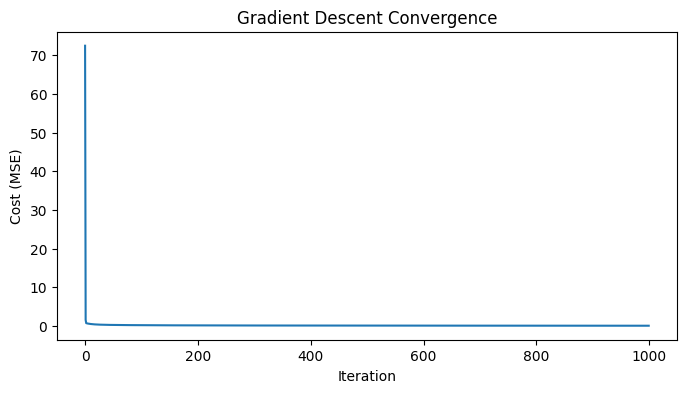

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent Convergence')
plt.show()

In [32]:
comparison = pd.DataFrame({
    'Normal_Equation': w_normal_eq,
    'Gradient_Descent': w_gd
})
print(comparison.head(10))

print("\nMax difference between methods:", np.max(np.abs(w_normal_eq - w_gd)))

   Normal_Equation  Gradient_Descent
0         1.717861          0.424953
1         0.063439          0.426340
2         0.059083          0.290646
3         0.073730          0.197753
4         0.015551          0.112413
5         0.007220          0.043247
6         0.009707          0.274827
7        -0.011086          0.549317
8         0.020506          0.203961
9        -0.047541          0.130754

Max difference between methods: 1.3016267245009738


# 9. Sklearn Model Implementation

In [ ]:
from sklearn.linear_model import LinearRegression

# sklearn ka model — note: yeh intercept khud handle karta hai,
# isliye X_train_dense (bina manual intercept column ke) use karo
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_dense, y_train_arr)

print("Intercept:", sklearn_model.intercept_)
print("Coefficients shape:", sklearn_model.coef_.shape)

Intercept: 10.787555030866391
Coefficients shape: (179,)


In [38]:
# Predictions (log scale pe, kyunki target log-transformed tha)

# Normal Equation
y_pred_normal_eq = X_test_b @ w_normal_eq

# Gradient Descent
y_pred_gd = X_test_b @ w_gd

# sklearn
y_pred_sklearn = sklearn_model.predict(X_test_dense)

print("Sample predictions comparison (log scale):")
print("Normal Eq:", y_pred_normal_eq[:5])
print("Grad Desc:", y_pred_gd[:5])
print("sklearn:  ", y_pred_sklearn[:5])

Sample predictions comparison (log scale):
Normal Eq: [11.88122225 12.7179697  11.57473112 11.88119434 12.84568716]
Grad Desc: [11.28520982 12.71353998 11.88474145 12.38831259 12.63316003]
sklearn:   [11.88122225 12.7179697  11.57473112 11.88119434 12.84568716]


In [39]:
comparison_all = pd.DataFrame({
    'Normal_Equation': w_normal_eq[1:],   # [0] intercept tha, baaki feature weights
    'Gradient_Descent': w_gd[1:],
    'sklearn': sklearn_model.coef_
})
print(comparison_all.head(10))

print("\nIntercept comparison:")
print(f"Normal Eq: {w_normal_eq[0]:.6f}, Grad Desc: {w_gd[0]:.6f}, sklearn: {sklearn_model.intercept_:.6f}")

   Normal_Equation  Gradient_Descent   sklearn
0         0.063439          0.426340  0.063439
1         0.059083          0.290646  0.059083
2         0.073730          0.197753  0.073730
3         0.015551          0.112413  0.015551
4         0.007220          0.043247  0.007220
5         0.009707          0.274827  0.009707
6        -0.011086          0.549317 -0.011086
7         0.020506          0.203961  0.020506
8        -0.047541          0.130754 -0.047541
9         0.472241         -0.017999  0.014144

Intercept comparison:
Normal Eq: 1.717861, Grad Desc: 0.424953, sklearn: 10.787555


# 10. Evaluation + Statistical Inference

In [40]:
import numpy as np

# Log scale se original scale mein convert karo
y_test_original = np.expm1(y_test_arr)

y_pred_normal_eq_original = np.expm1(y_pred_normal_eq)
y_pred_gd_original = np.expm1(y_pred_gd)
y_pred_sklearn_original = np.expm1(y_pred_sklearn)

In [41]:
def evaluate_model(y_true, y_pred, n_features, model_name):
    n = len(y_true)
    
    # SS_tot aur SS_res (yaad karo — humne yeh derive kiya tha)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    
    r2 = 1 - (ss_res / ss_tot)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    
    print(f"\n--- {model_name} ---")
    print(f"R²:          {r2:.4f}")
    print(f"Adjusted R²: {adj_r2:.4f}")
    print(f"RMSE:        {rmse:.2f}")
    print(f"MAE:         {mae:.2f}")
    
    return {'model': model_name, 'r2': r2, 'adj_r2': adj_r2, 'rmse': rmse, 'mae': mae}

n_features = X_test_dense.shape[1]

results_normal_eq = evaluate_model(y_test_original, y_pred_normal_eq_original, n_features, "Normal Equation")
results_gd = evaluate_model(y_test_original, y_pred_gd_original, n_features, "Gradient Descent")
results_sklearn = evaluate_model(y_test_original, y_pred_sklearn_original, n_features, "sklearn")


--- Normal Equation ---
R²:          0.8539
Adjusted R²: 0.6204
RMSE:        33477.01
MAE:         22083.92

--- Gradient Descent ---
R²:          -0.0630
Adjusted R²: -1.7618
RMSE:        90295.10
MAE:         59018.14

--- sklearn ---
R²:          0.8562
Adjusted R²: 0.6264
RMSE:        33211.43
MAE:         21892.58


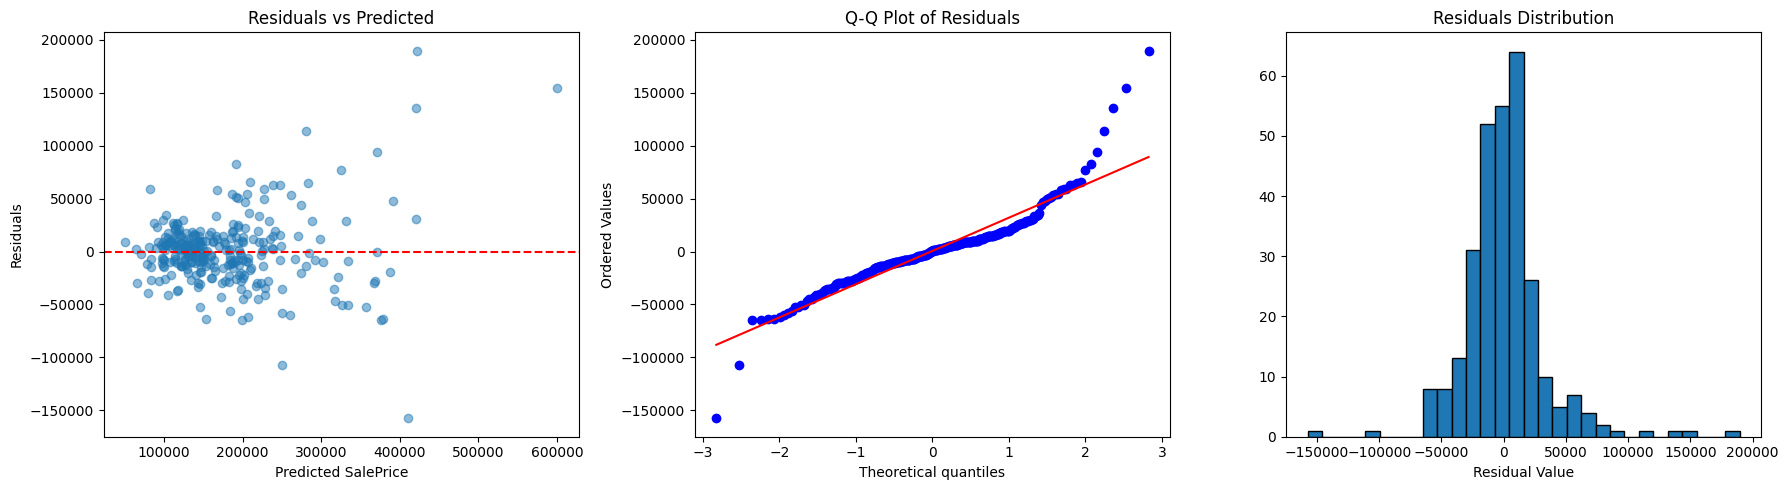

In [42]:
import matplotlib.pyplot as plt
from scipy import stats

# sklearn predictions use karte hai residual analysis ke liye (sabse reliable)
residuals = y_test_original - y_pred_sklearn_original

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Residuals vs Predicted (Homoscedasticity check - Assumption 3)
axes[0].scatter(y_pred_sklearn_original, residuals, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted SalePrice')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Plot 2: Q-Q Plot (Normality check - Assumption 4)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

# Plot 3: Residuals Histogram
axes[2].hist(residuals, bins=30, edgecolor='black')
axes[2].set_title('Residuals Distribution')
axes[2].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()

In [45]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from pprint import pprint

# Breusch-Pagan test ke liye statsmodels OLS model chahiye hota hai
X_test_with_const = sm.add_constant(X_test_dense)
ols_model_for_bp = sm.OLS(y_test_original, X_test_with_const).fit()

bp_test = het_breuschpagan(ols_model_for_bp.resid, ols_model_for_bp.model.exog)
labels = ['LM Statistic', 'LM p-value', 'F-Statistic', 'F p-value']
pprint(dict(zip(labels, bp_test)))

{'F p-value': np.float64(0.0028344859709211706),
 'F-Statistic': np.float64(1.5830649788761173),
 'LM Statistic': np.float64(163.83151850297057),
 'LM p-value': np.float64(0.7852403984331588)}


In [44]:
import statsmodels.api as sm


# Train data pe OLS fit karo (statsmodels version, inference ke liye)
X_train_with_const = sm.add_constant(X_train_dense)
ols_model = sm.OLS(y_train_arr, X_train_with_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     49.62
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        04:02:31   Log-Likelihood:                 678.39
No. Observations:                1168   AIC:                            -1055.
Df Residuals:                    1017   BIC:                            -290.3
Df Model:                         150                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7179      0.024     70.516      0.0

In [46]:
# Sirf significant coefficients nikaalo (p < 0.05)
p_values = ols_model.pvalues
significant_features_model = p_values[p_values < 0.05]
print(f"\nSignificant coefficients: {len(significant_features_model)} out of {len(p_values)}")


Significant coefficients: 148 out of 180
